In [1]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

In [2]:
PROTEOME_LOCAL_DIR = Path('data/heavy/proteome/obs_pred')


def resolve_local_paths_for_targets(
    proteome_targets: list[str],
    data_dir: Path = PROTEOME_LOCAL_DIR,
) -> dict[str, Path]:
    """proteome_target -> local CSV path (matched by exact filename '<target>.csv')."""
    data_dir = Path(data_dir)
    resolved: dict[str, Path] = {}
    missing: list[str] = []
    for target in proteome_targets:
        path = data_dir / f'{target}.csv'
        if path.exists():
            resolved[target] = path
        else:
            missing.append(target)

    if missing:
        raise FileNotFoundError(
            f'No matching CSV under {data_dir} for: {missing}'
        )
    return resolved

# 自社データから指定カラム(observed / predicted)を読み込む
def _load_one_series_named(path: Path, column_name: str, value_col: str = 'observed') -> pd.Series:
    df = pd.read_csv(path, usecols=['sample_id', value_col])
    return df.set_index('sample_id')[value_col].rename(column_name)


def _load_proteome_value_from_list(
    df_list: pd.DataFrame,
    *,
    value_col: str,
    target_col: str = 'proteome_target',
    column_col: str = 'episcore_column',
    data_dir: Path = PROTEOME_LOCAL_DIR,
    max_workers: int = 32,
) -> pd.DataFrame:
    """Load local prediction CSVs matched to df_list[target_col], join on sample_id."""
    mapping = (
        df_list[[column_col, target_col]]
        .dropna()
        .astype({target_col: str, column_col: str})
    )
    path_by_target = resolve_local_paths_for_targets(
        mapping[target_col].unique().tolist(),
        data_dir=data_dir,
    )

    jobs = [
        (path_by_target[target], col)
        for target, col in mapping[[target_col, column_col]].itertuples(index=False, name=None)
    ]

    series_list: list[pd.Series] = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(_load_one_series_named, path, col, value_col): col
            for path, col in jobs
        }
        for future in as_completed(futures):
            series_list.append(future.result())

    wide = pd.concat(series_list, axis=1)
    dup_cols = wide.columns[wide.columns.duplicated()]
    if len(dup_cols):
        raise ValueError(f'Duplicate column names: {dup_cols.tolist()}')

    return wide.reset_index()


def load_proteome_observed_from_list(
    df_list: pd.DataFrame,
    *,
    target_col: str = 'proteome_target',
    column_col: str = 'episcore_column',
    data_dir: Path = PROTEOME_LOCAL_DIR,
    max_workers: int = 32,
) -> pd.DataFrame:
    """observedカラムを集約して1つのDataFrameを生成する。"""
    return _load_proteome_value_from_list(
        df_list,
        value_col='observed',
        target_col=target_col,
        column_col=column_col,
        data_dir=data_dir,
        max_workers=max_workers,
    )


def load_proteome_predicted_from_list(
    df_list: pd.DataFrame,
    *,
    target_col: str = 'proteome_target',
    column_col: str = 'episcore_column',
    data_dir: Path = PROTEOME_LOCAL_DIR,
    max_workers: int = 32,
) -> pd.DataFrame:
    """predictedカラムを集約して1つのDataFrameを生成する。"""
    return _load_proteome_value_from_list(
        df_list,
        value_col='predicted',
        target_col=target_col,
        column_col=column_col,
        data_dir=data_dir,
        max_workers=max_workers,
    )

In [3]:
df_hash_mapping = pd.read_csv('data/kenshin_ID_SEX_AGE_20260302.csv')
df_proteome_list = pd.read_csv('data/確信強_ver2.csv')  # CRPは入っていない
df_proteome_list = df_proteome_list[['episcore_column', 'proteome_target']]
df_proteome_observed = load_proteome_observed_from_list(df_proteome_list)
df_crp = pd.read_csv('data/heavy/kenshin/obs_pred/crp.csv')
df_proteome_ours_predicted = load_proteome_predicted_from_list(df_proteome_list)
df_mdr_predicted = pd.read_csv('output/clock/Episcores.csv').rename(columns={'ID': 'msa_filename'})

In [4]:
df_observed = df_crp.drop(columns=['predicted']).merge(df_proteome_observed, left_on='sample_id', right_on='sample_id', how='inner')
df_observed = df_observed.rename(columns={'observed': 'CRP'})
df_observed = df_hash_mapping.merge(
    df_observed,
    left_on='個人ID',
    right_on='sample_id',
    how='inner',
).drop(columns=['個人ID', 'sample_id', '性別', '年齢'])

df_ours_predicted = df_crp.drop(columns=['observed']).merge(df_proteome_ours_predicted, left_on='sample_id', right_on='sample_id', how='inner')
df_ours_predicted = df_ours_predicted.rename(columns={'predicted': 'CRP'})
df_ours_predicted = df_hash_mapping.merge(
    df_ours_predicted,
    left_on='個人ID',
    right_on='sample_id',
    how='inner',
).drop(columns=['個人ID', 'sample_id', '性別', '年齢'])

df_mdr_predicted = df_mdr_predicted[df_ours_predicted.columns]

In [5]:
df_ours_predicted

,msa_filename,CRP,Coagulation factor VII,B2-microglobulin,Afamin,G.CSF,CXCL10,ESM-1,ENPP7,BCAM,...,WFIKKN2,VCAM1,NOTCH1,RARRES2,SKR3,TGF.alpha,SERPIN A3,THBS2,VEGFA,Trypsin-2
0,209788070049_R02C02,-2.502830,0.004447,0.019423,-0.001021,0.232529,0.132318,-0.046479,0.207332,-0.050838,...,-0.090160,0.038226,-0.017199,-0.086742,0.002299,0.045486,0.027763,0.017600,0.047719,0.016047
1,209788070049_R09C03,-2.855938,-0.035705,-0.059323,-0.000119,-0.203667,-0.265651,-0.047644,-0.092185,-0.038716,...,0.044745,-0.032640,0.009240,-0.176915,-0.004776,-0.076278,-0.036167,0.051307,-0.038266,0.059357
2,209788070049_R13C03,-2.753971,-0.008650,0.070848,0.039813,-0.178040,0.303266,0.008052,-0.392071,-0.046207,...,0.034992,0.105389,-0.020395,-0.120376,0.021939,-0.064558,-0.015307,0.072522,0.035979,0.104574
3,209788070049_R14C03,-2.926022,-0.015864,-0.011322,-0.002244,-0.341875,-0.119157,-0.022119,0.100584,0.105289,...,0.040188,0.025374,0.069898,-0.195151,-0.001427,-0.041643,-0.032271,0.013574,-0.059193,-0.003269
4,209788070052_R15C02,-2.693003,0.004896,0.082930,0.024562,-0.099940,0.097834,-0.027021,-0.198658,0.103278,...,-0.009398,0.024704,0.063542,-0.030094,0.076057,0.025219,0.002814,-0.009349,0.045532,0.043604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,210095290015_R05C03,-2.667002,0.000765,0.044077,-0.018021,0.100116,0.109051,-0.041307,0.226157,0.022170,...,-0.154651,0.015334,0.055707,-0.116737,-0.028767,0.023834,0.014373,0.010597,-0.002101,0.003121
433,210095290015_R04C03,-2.771412,0.054835,0.095035,0.011275,-0.218398,0.150814,0.151967,-0.790231,0.071206,...,0.081069,0.042442,-0.000209,0.037837,0.132741,0.049533,-0.006092,-0.037590,0.046302,0.002445
434,210095290015_R16C02,-2.891098,-0.018376,0.006035,-0.000232,-0.393223,0.020369,0.086068,-0.146970,-0.007209,...,0.017915,0.010935,-0.006410,-0.091267,-0.016484,-0.010923,-0.031706,0.036496,-0.025672,0.004014
435,210095290015_R08C03,-2.342351,-0.004138,-0.045659,-0.010254,0.549187,0.194264,-0.226125,-0.832280,-0.025371,...,-0.092706,0.028103,-0.009899,0.100512,-0.056477,0.013041,0.029887,0.076454,0.010781,-0.028836


In [6]:
df_mdr_predicted

,msa_filename,CRP,Coagulation factor VII,B2-microglobulin,Afamin,G.CSF,CXCL10,ESM-1,ENPP7,BCAM,...,WFIKKN2,VCAM1,NOTCH1,RARRES2,SKR3,TGF.alpha,SERPIN A3,THBS2,VEGFA,Trypsin-2
0,209788070040_R07C01,-0.113913,0.047160,-0.322272,-0.008346,-0.009035,0.153725,-0.240858,-0.033797,0.000565,...,0.036798,0.006025,0.065985,0.030160,0.167762,-0.001523,0.176469,-0.105261,0.110144,-0.091570
1,209788070040_R08C03,-0.131226,0.045108,-0.351092,-0.005484,-0.018356,0.126377,-0.238296,-0.043039,0.000848,...,0.056384,-0.007130,0.076227,0.017593,0.160609,-0.022202,0.152510,-0.119121,0.099587,-0.104141
2,209788070040_R09C02,-0.123932,0.044415,-0.337635,-0.004940,-0.021025,0.139080,-0.234436,-0.034223,0.000895,...,0.050953,-0.000848,0.072505,0.020063,0.163479,-0.009793,0.149411,-0.112058,0.104125,-0.100705
3,209788070040_R10C03,-0.125714,0.044952,-0.364251,-0.001023,-0.009453,0.116498,-0.232881,-0.040154,0.000895,...,0.057481,-0.008366,0.074491,0.020921,0.164193,-0.013831,0.149609,-0.120615,0.099391,-0.105993
4,209788070040_R15C03,-0.134662,0.045057,-0.371362,-0.008832,-0.023052,0.116702,-0.244095,-0.041154,0.000942,...,0.046036,-0.013808,0.072954,0.008896,0.154797,-0.014122,0.159653,-0.115142,0.095803,-0.101370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,210095290015_R08C03,-0.124452,0.045936,-0.361045,-0.014680,-0.008430,0.135564,-0.243118,-0.055703,0.000895,...,0.051843,-0.009270,0.072638,0.015872,0.160095,-0.005123,0.170261,-0.113966,0.094567,-0.111874
436,210095290015_R09C02,-0.120236,0.043653,-0.338450,-0.014159,-0.013410,0.122226,-0.242227,-0.037104,0.000753,...,0.057144,-0.009905,0.064623,0.022276,0.158388,-0.017599,0.157146,-0.112591,0.096628,-0.090885
437,210095290015_R12C02,-0.130655,0.047360,-0.378411,-0.013846,-0.021650,0.108184,-0.245375,-0.048487,0.000753,...,0.057180,-0.018027,0.073485,0.020143,0.158252,-0.011991,0.176792,-0.123942,0.089657,-0.108944
438,210095290015_R14C01,-0.136171,0.044157,-0.364605,-0.005312,-0.021187,0.118211,-0.245449,-0.045391,0.000518,...,0.058785,-0.011856,0.075571,0.008981,0.164911,-0.014295,0.152627,-0.123451,0.098446,-0.109399


In [7]:
df_observed

,msa_filename,CRP,ESM-1,CCL21,CXCL10,HGFA,Coagulation factor VII,Granzyme A,Galectin-4,CD48 antigen,...,Resistin,WFIKKN2,RARRES2,PIGR,Stanniocalcin-1,VCAM1,THBS2,TNFRSF17,SMPD1,TNFRSF1B
0,209788070049_R02C02,-1.771957,-0.054110,0.002833,0.537918,-0.004914,0.663003,0.268250,-0.088700,0.489213,...,1.558311,-0.024647,0.236478,0.218464,0.925048,0.196877,-0.128239,0.362729,0.386901,0.371842
1,209788070049_R09C03,-2.995732,-0.229474,0.412375,1.070794,-0.052371,-0.046312,-0.111865,0.246104,-0.018412,...,-0.271566,0.260711,0.109542,0.100671,-0.026270,-0.141006,-0.319261,-0.306079,-0.193985,0.364084
2,209788070049_R13C03,-2.813411,-0.297317,0.201147,0.627548,0.071644,0.452823,0.723528,0.789955,0.088587,...,0.661182,-0.041207,0.279261,0.992597,0.717694,0.206436,0.396135,0.406079,-0.053903,0.190062
3,209788070049_R14C03,-2.995732,-0.480787,0.106242,-0.504026,-0.009016,0.028383,-1.316261,-0.058897,-0.210050,...,-0.478123,-0.116971,-0.420491,0.232493,-0.447843,-0.172113,-0.501058,0.122302,0.329075,0.500514
4,209788070052_R15C02,-2.995732,-0.376398,0.431714,0.010412,-0.299544,-0.371559,-0.220965,-0.093617,0.081936,...,-0.378806,0.073940,-0.285718,0.046504,0.224572,-0.054041,-0.627376,-0.049135,0.225916,-0.357539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,210095290015_R05C03,-2.120264,0.204067,-0.322084,-0.736315,-0.417208,-0.492713,-0.181852,-0.123202,-0.385767,...,0.788264,-0.387578,-0.030738,-0.058009,-0.114617,-0.139722,-0.480576,-0.248844,-0.045514,-0.081968
433,210095290015_R04C03,-2.995732,0.018567,0.071241,-0.101241,-0.230205,-0.272366,-0.123562,0.153147,-0.346637,...,-1.099194,-0.314128,-0.824026,-0.634815,-0.408675,-0.084980,-0.769571,-0.273877,-0.085844,-0.293887
434,210095290015_R16C02,-2.995732,-0.484027,-0.028702,0.332703,0.012017,-0.591572,0.497110,-0.248278,-0.609127,...,-0.679571,-0.316172,-0.752364,-0.384869,-0.011565,0.157439,-0.430837,-0.239092,-0.180313,-0.341243
435,210095290015_R08C03,-2.659260,-0.583658,-0.656818,0.601020,-0.031576,0.339492,0.947464,-0.656267,-0.024764,...,1.687448,-0.145016,0.626070,0.471499,-0.370964,-0.037773,-0.205853,-0.926032,0.147794,0.393202


In [8]:
def pearson_observed_vs_predicted(
    df_observed: pd.DataFrame,
    df_predicted: pd.DataFrame,
    *,
    id_col: str = 'msa_filename',
) -> pd.DataFrame:
    """Align by sample_id and compute per-column Pearson r between observed and united."""
    obs = df_observed.set_index(id_col)
    pred = df_predicted.set_index(id_col)

    common_ids = obs.index.intersection(pred.index)
    common_cols = [c for c in obs.columns if c in pred.columns]
    if not len(common_ids):
        raise ValueError('No overlapping sample_id between df_observed and df_united.')
    if not common_cols:
        raise ValueError('No overlapping protein columns between df_observed and df_united.')

    obs_a = obs.loc[common_ids, common_cols].apply(pd.to_numeric, errors='coerce')
    pred_a = pred.loc[common_ids, common_cols].apply(pd.to_numeric, errors='coerce')

    rows = []
    for col in common_cols:
        x, y = obs_a[col], pred_a[col]
        mask = x.notna() & y.notna()
        n = int(mask.sum())
        if n >= 2 and x[mask].std() > 0 and y[mask].std() > 0:
            r, p = pearsonr(x[mask], y[mask])
        else:
            r, p = float('nan'), float('nan')
        rows.append({'column': col, 'n': n, 'pearson_r': r, 'p_value': p})

    return (
        pd.DataFrame(rows)
        .sort_values('pearson_r', ascending=False, na_position='last')
        .reset_index(drop=True)
    )

In [9]:
df_corr_ours = pearson_observed_vs_predicted(df_observed, df_ours_predicted).drop(columns=['n'])
print(f'shared index: {df_observed["msa_filename"].isin(df_ours_predicted["msa_filename"]).sum()}')
print(f'shared columns  : {len(df_corr_ours)}')
df_corr_ours

shared index: 437
shared columns  : 94


/var/folders/mw/xp7bf1k50zl_vvc56p0y3xdw0000gq/T/ipykernel_79345/1660661214.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(x[mask], y[mask])


,column,pearson_r,p_value
0,ICAM5,0.635655,2.097077e-44
1,ENPP7,0.634275,3.661473e-44
2,Resistin,0.608572,7.163377e-40
3,NEP,0.588133,9.952661e-37
4,SIGLEC1,0.564950,2.008890e-33
...,...,...,...
89,CCL21,NaN,NaN
90,CHIT-1,NaN,NaN
91,Insulin receptor,NaN,NaN
92,N.CDase,NaN,NaN


In [10]:
df_corr_mdr = pearson_observed_vs_predicted(df_observed, df_mdr_predicted).drop(columns=['n'])
print(f'shared index: {df_observed["msa_filename"].isin(df_mdr_predicted["msa_filename"]).sum()}')
print(f'shared columns  : {len(df_corr_mdr)}')
df_corr_mdr

shared index: 437
shared columns  : 94


,column,pearson_r,p_value
0,G.CSF,0.516871,2.419219e-27
1,SHBG,0.512737,7.285126e-27
2,Resistin,0.495597,6.015223e-25
3,Aminoacylase-1,0.487809,4.121729e-24
4,NEP,0.462718,1.469322e-21
...,...,...,...
89,MIA,0.013047,7.998775e-01
90,HGFA,-0.009771,8.494283e-01
91,NMNAT1,-0.021091,6.819347e-01
92,SMPD1,-0.030136,5.581069e-01


In [11]:
df_corr_united = df_corr_ours.merge(
    df_corr_mdr,
    left_on='column',
    right_on='column',
    how='inner',
)

df_corr_united = df_corr_united.drop(columns=['column'])
df_corr_united = df_corr_united.rename(columns={'pearson_r_x': 'pearson_r_ema', 'pearson_r_y': 'pearson_r_epi', 'p_value_x': 'pvalue_ema', 'p_value_y': 'pvalue_epi'})
# df_corr_united = df_corr_united.rename(columns={'pearson_p_value': 'pvalue_x', 'p_value': 'pvalue_y'})
df_corr_united

,pearson_r_ema,pvalue_ema,pearson_r_epi,pvalue_epi
0,0.635655,2.097077e-44,0.277136,3.962221e-08
1,0.634275,3.661473e-44,0.289761,8.727438e-09
2,0.608572,7.163377e-40,0.495597,6.015223e-25
3,0.588133,9.952661e-37,0.462718,1.469322e-21
4,0.564950,2.008890e-33,0.448093,3.632856e-20
...,...,...,...,...
89,NaN,NaN,0.027842,5.884656e-01
90,NaN,NaN,0.067331,1.903004e-01
91,NaN,NaN,0.066933,1.929438e-01
92,NaN,NaN,0.091908,7.353373e-02


In [12]:
df_corr_united.to_csv('output/pearson_r_comparison.csv', index=False)

In [18]:
df_corr_united

,episcore_column,pearson_r_x,pearson_r_y
0,ADAMTS,0.186222,0.142560
1,Afamin,0.105882,0.080002
2,Aminoacylase-1,0.132136,0.487809
3,B2-microglobulin,0.359401,0.389696
4,BCAM,0.111923,0.050855
...,...,...,...
68,TNFRSF17,0.064703,0.079902
69,TNFRSF1B,0.240979,0.279103
70,VCAM1,0.202295,0.304217
71,VEGFA,0.269288,0.115193


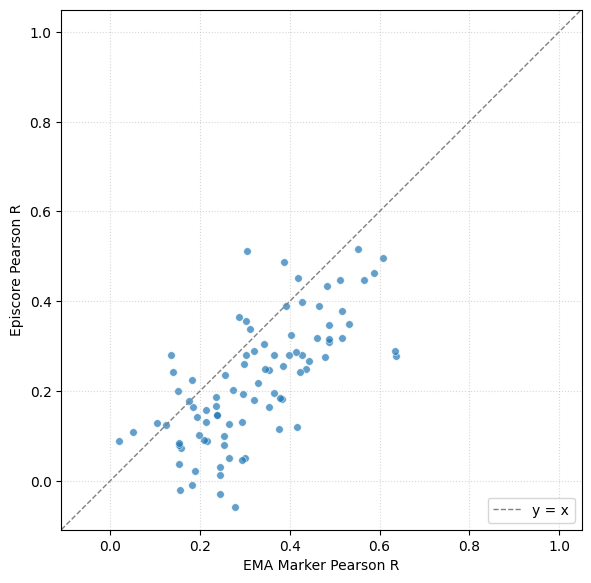

In [14]:
x = df_corr_united['pearson_r_ema']
y = df_corr_united['pearson_r_epi']

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, s=30, alpha=0.7, edgecolor='white', linewidth=0.5)

lim_lo = min(x.min(), y.min(), 0) - 0.05
lim_hi = max(x.max(), y.max(), 1) + 0.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], color='gray', linestyle='--', linewidth=1, label='y = x')
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel('EMA Marker Pearson R')
ax.set_ylabel('Episcore Pearson R')
# ax.set_title('Pearsonの相関係数')
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

fig.savefig('output/pearson_r_comparison.png')